<a href="https://colab.research.google.com/github/karimsaari-data/dark_massilia/blob/main/upscaler_4k.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🚀 Ultra Upscaler — Real-ESRGAN + Stable Diffusion
**Pipeline :** Real-ESRGAN x4 → SD img2img tiled (ajout de détails IA)

Assure-toi d'avoir activé le GPU : **Exécution → Modifier le type d'exécution → GPU T4**

In [1]:
# ✅ ÉTAPE 1 — Vérification GPU
import torch
print('GPU dispo :', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU :', torch.cuda.get_device_name(0))
    print('VRAM :', round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1), 'GB')
else:
    print('⚠️ Pas de GPU ! Va dans Exécution → Modifier le type d\'exécution → GPU')

GPU dispo : True
GPU : Tesla T4
VRAM : 15.6 GB


In [2]:
# ✅ ÉTAPE 2 — Installation des dépendances
!pip install -q "diffusers==0.30.3" "transformers==4.44.2" accelerate
!pip install -q basicsr facexlib gfpgan realesrgan
!pip install -q Pillow numpy opencv-python-headless

# Fix torchvision compatibility
import torchvision.transforms.functional as F
import types, sys
ft = types.ModuleType('torchvision.transforms.functional_tensor')
ft.rgb_to_grayscale = F.rgb_to_grayscale
sys.modules['torchvision.transforms.functional_tensor'] = ft
print('Installation terminée ✅')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 52.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 90.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 40.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 73.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.5/172.5 kB 6.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.8/46.8 kB 5.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.0/178.0 kB 21.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.6/59.6 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.2/52.2 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 333.1/333.1 kB 32.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5

In [3]:
# ✅ ÉTAPE 3 — Upload de ton image
from google.colab import files
print('Sélectionne ton image (JPG ou PNG)...')
uploaded = files.upload()
input_filename = list(uploaded.keys())[0]
print(f'Image uploadée : {input_filename}')

Sélectionne ton image (JPG ou PNG)...


Saving enhanced_image_215059.png to enhanced_image_215059.png
Image uploadée : enhanced_image_215059.png


Image source : 1344x768 px
	Tile 1/6
	Tile 2/6
	Tile 3/6
	Tile 4/6
	Tile 5/6
	Tile 6/6
Real-ESRGAN terminé : 5376x3072 px ✅


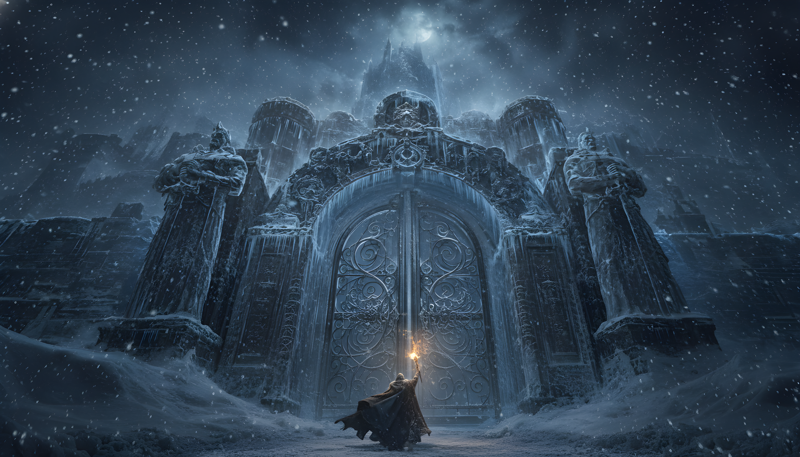

In [4]:
# ✅ ÉTAPE 4 — Real-ESRGAN x4 (première passe)
import cv2
import numpy as np
from PIL import Image
from realesrgan import RealESRGANer
from basicsr.archs.rrdbnet_arch import RRDBNet
import torch
import os

# Téléchargement du modèle
!wget -q https://github.com/xinntao/Real-ESRGAN/releases/download/v0.1.0/RealESRGAN_x4plus.pth -P /content/weights/

model = RRDBNet(num_in_ch=3, num_out_ch=3, num_feat=64, num_block=23, num_grow_ch=32, scale=4)
upsampler = RealESRGANer(
    scale=4,
    model_path='/content/weights/RealESRGAN_x4plus.pth',
    model=model,
    tile=512,
    tile_pad=10,
    pre_pad=0,
    half=torch.cuda.is_available()
)

img = cv2.imread(input_filename, cv2.IMREAD_UNCHANGED)
print(f'Image source : {img.shape[1]}x{img.shape[0]} px')

output, _ = upsampler.enhance(img, outscale=4)
esrgan_path = 'esrgan_output.png'
cv2.imwrite(esrgan_path, output)
print(f'Real-ESRGAN terminé : {output.shape[1]}x{output.shape[0]} px ✅')

# Aperçu
from IPython.display import display
img_pil = Image.open(esrgan_path)
preview = img_pil.copy()
preview.thumbnail((800, 600))
display(preview)

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

Chargement Stable Diffusion (1-2 min)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

...

Tuile 38/40 ✓


  0%|          | 0/5 [00:00<?, ?it/s]

Tuile 39/40 ✓


  0%|          | 0/5 [00:00<?, ?it/s]

Tuile 40/40 ✓

Terminé ! 5376x3072 px ✅


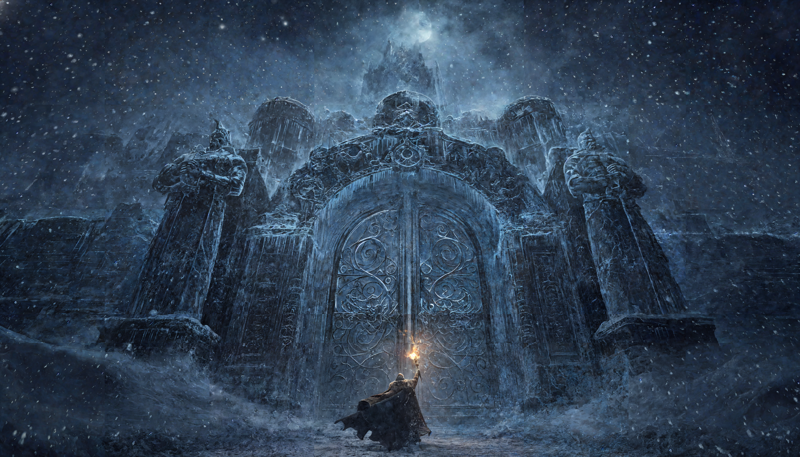

In [5]:
# ✅ ÉTAPE 5 — SD img2img tiled (ajout de détails IA)
# Paramètres — ajuste selon le résultat voulu
DENOISING_STRENGTH = 0.25   # 0.15 = subtil | 0.35 = plus de détails ajoutés
PROMPT = "highly detailed, 8k, sharp focus, photorealistic, intricate details"
NEGATIVE_PROMPT = "blurry, low quality, artifacts, noise"
TILE_SIZE = 768              # Taille tuile (réduire si manque VRAM)
TILE_OVERLAP = 64
STEPS = 20

from diffusers import StableDiffusionImg2ImgPipeline
import torch
from PIL import Image
import numpy as np

# Chargement modèle SD
print('Chargement Stable Diffusion (1-2 min)...')
pipe = StableDiffusionImg2ImgPipeline.from_pretrained(
    'runwayml/stable-diffusion-v1-5',
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    safety_checker=None
)
pipe = pipe.to('cuda' if torch.cuda.is_available() else 'cpu')
pipe.enable_attention_slicing()
print('Modèle chargé ✅')

# Upscale tuilé
def sd_tiled_upscale(image_path, prompt, negative_prompt, strength, tile_size, overlap, steps):
    img = Image.open(image_path).convert('RGB')
    w, h = img.size
    print(f'Traitement image {w}x{h} en tuiles de {tile_size}px...')

    result = Image.new('RGB', (w, h))
    stride = tile_size - overlap

    tiles_x = max(1, (w - overlap + stride - 1) // stride)
    tiles_y = max(1, (h - overlap + stride - 1) // stride)
    total = tiles_x * tiles_y
    count = 0

    for ty in range(tiles_y):
        for tx in range(tiles_x):
            x = min(tx * stride, w - tile_size)
            y = min(ty * stride, h - tile_size)
            x = max(0, x)
            y = max(0, y)

            tile = img.crop((x, y, x + tile_size, y + tile_size))

            enhanced = pipe(
                prompt=prompt,
                negative_prompt=negative_prompt,
                image=tile,
                strength=strength,
                num_inference_steps=steps,
                guidance_scale=7.5
            ).images[0]

            result.paste(enhanced, (x, y))
            count += 1
            print(f'Tuile {count}/{total} ✓')

    return result

final = sd_tiled_upscale(esrgan_path, PROMPT, NEGATIVE_PROMPT, DENOISING_STRENGTH, TILE_SIZE, TILE_OVERLAP, STEPS)
final_path = 'final_ultra_4k.png'
final.save(final_path)
print(f'\nTerminé ! {final.size[0]}x{final.size[1]} px ✅')

preview2 = final.copy()
preview2.thumbnail((800, 600))
display(preview2)

In [7]:
# ✅ ÉTAPE 6 — Téléchargement du résultat
from google.colab import files
print('Téléchargement de final_ultra_4k.png...')
files.download('final_ultra_4k.png')

# Optionnel : télécharger aussi le résultat Real-ESRGAN seul
# files.download('esrgan_output.png')

Téléchargement de final_ultra_4k.png...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>